# Task 1: Data Loading and Preprocessing

All reusable functions are in `src/functions.py`. Here we demonstrate the full pipeline.

In [1]:
import sys
sys.path.append('../src')
from functions import *

## 1.1 Data Splitting

We load `development_data.csv` and split 80% train / 20% validation, stratified by age with seed=42.

`evaluation_data.csv` is **locked** — never used for any design decision.

In [2]:
development_df, train_df, val_df, evaluation_df = load_data_preprocessing(
    development_path='../data/development_data.csv',
    evaluation_path='../data/evaluation_data.csv'
)


Loading development dataset

Loading dataset from: ../data/development_data.csv
The first rows of the dataset             age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.

## 1.2 Preprocessing

**Missing values:** We use **median imputation** because CpG methylation values can be skewed, making median more robust than mean. Under MCAR, this does not introduce bias. The imputer is fit only on training data.

**Categorical features:** `sex` and `ethnicity` are one-hot encoded. They may carry demographic signal for age.

**Feature scaling:** StandardScaler applied to CpG features inside a sklearn Pipeline.

All steps are fit on training data only — then transform-only on validation and evaluation.

In [3]:
metadata_cols, cpg_cols, target_col = get_feature_groups(train_df)
print('Metadata columns:', metadata_cols)
print('Number of CpG columns:', len(cpg_cols))
print('Target:', target_col)

Metadata columns: ['sex', 'ethnicity']
Number of CpG columns: 1000
Target: age


### Feature Matrices

We build 3 combinations to evaluate how much signal comes from metadata vs CpG:
- **metadata only** — demographic baseline
- **cpg only** — methylation signal
- **all** — combined

In [4]:
for feature_name in ['metadata', 'cpg', 'all']:
    feature_cols     = get_feature_set(train_df, feature_set=feature_name)
    X_train, y_train = split_features_target(train_df, feature_cols)
    X_val,   y_val   = split_features_target(val_df,   feature_cols)
    selected_meta    = [c for c in metadata_cols if c in feature_cols]
    selected_cpg     = [c for c in cpg_cols      if c in feature_cols]
    preprocessor     = build_preprocessor(selected_cpg, selected_meta)
    X_train_p        = preprocessor.fit_transform(X_train)
    X_val_p          = preprocessor.transform(X_val)
    print(f'\n{feature_name.upper()}: X_train={X_train_p.shape}, X_val={X_val_p.shape}')


METADATA: X_train=(364, 4), X_val=(92, 4)

CPG: X_train=(364, 1000), X_val=(92, 1000)

ALL: X_train=(364, 1004), X_val=(92, 1004)


## 1.3 Exploratory Analysis

     Split   N Age Mean±Std Age Range  Male  Female
     Train 364  64.5 ± 14.6  19 - 101   191     173
Validation  92  64.2 ± 14.7   25 - 89    41      51
Evaluation 100  62.5 ± 14.3   21 - 92    42      58


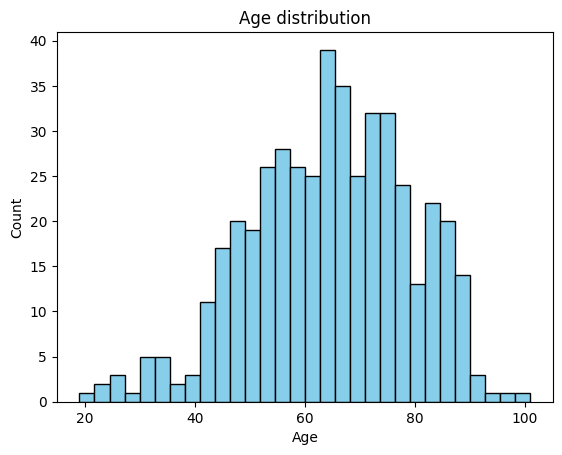

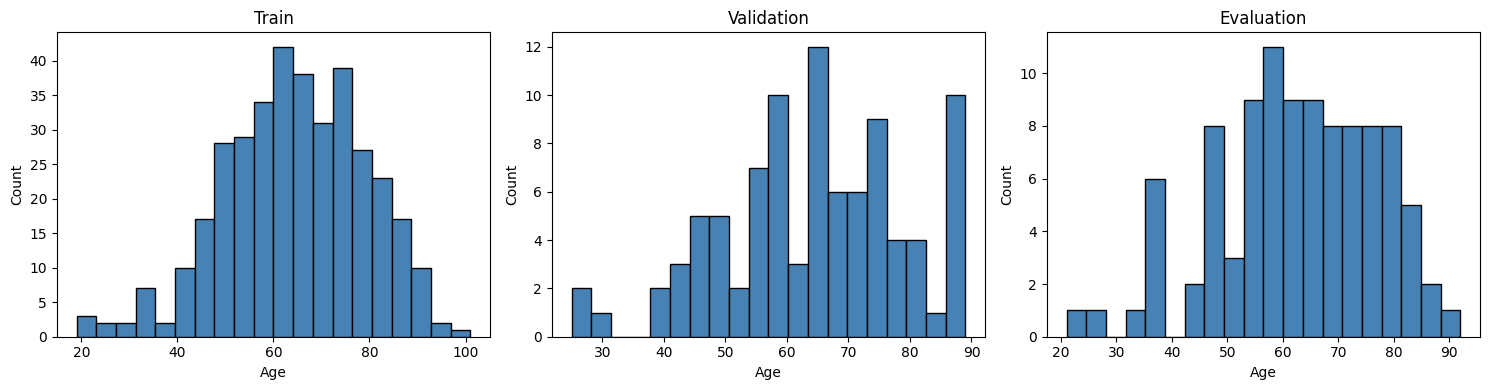


--- Missing Values ---

Checking missing values
Total missing values: 10965

Missing values in column: cg26330518    26
cg04193015    24
cg12233363    22
cg27314669    21
cg25410668    20
cg01804382    20
cg24998110    20
cg08128734    20
cg04999352    20
cg07234388    20
dtype: int64

Dataset: Training set
Number of samples: 364
Age mean: 64.51
Age std: 14.64
Age range: 19 - 101

Sex balance:
sex
M    191
F    173
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    246
Hispanic - Mexican      118
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 10965

Dataset: Validation set
Number of samples: 92
Age mean: 64.22
Age std: 14.69
Age range: 25 - 89

Sex balance:
sex
F    51
M    41
Name: count, dtype: int64

Ethnicity balance:
ethnicity
Caucasian - European    62
Hispanic - Mexican      30
Name: count, dtype: int64

Number of CpG columns: 1000
Total missing values: 2747

Dataset: Evaluation set
Number of samples: 100
Age mean: 62.5

In [5]:
exploratory_analysis(train_df, val_df, evaluation_df, development_df)

## Justification Summary

**Missing values:** Median imputation was chosen because CpG methylation values can be skewed. Under MCAR, median imputation does not introduce bias. The imputer is always fit only on training data to avoid data leakage.

**Categorical features:** `sex` and `ethnicity` are one-hot encoded so they can be used numerically by models. Including them tests whether demographic variables add predictive signal for age on top of CpG features.

**Feature matrices:** Three combinations (metadata only / CpG only / all) allow us to isolate how much each group contributes to age prediction.

**No additional cleaning steps** were performed — no duplicate rows or clearly erroneous values were detected.